In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
import plotly.express as px


In [ ]:
try:
    df=pd.read_csv('crocodile_dataset.csv')
    print('Dataset Loaded Successfully')
except:
    print('Dataset not found')

Dataset Loaded Successfully


In [ ]:
df.head()


,Observation ID,Common Name,Scientific Name,Family,Genus,Observed Length (m),Observed Weight (kg),Age Class,Sex,Date of Observation,Country/Region,Habitat Type,Conservation Status,Observer Name,Notes
0,1,Morelet's Crocodile,Crocodylus moreletii,Crocodylidae,Crocodylus,1.90,62.0,Adult,Male,31-03-2018,Belize,Swamps,Least Concern,Allison Hill,Cause bill scientist nation opportunity.
1,2,American Crocodile,Crocodylus acutus,Crocodylidae,Crocodylus,4.09,334.5,Adult,Male,28-01-2015,Venezuela,Mangroves,Vulnerable,Brandon Hall,Ago current practice nation determine operatio...
2,3,Orinoco Crocodile,Crocodylus intermedius,Crocodylidae,Crocodylus,1.08,118.2,Juvenile,Unknown,07-12-2010,Venezuela,Flooded Savannas,Critically Endangered,Melissa Peterson,Democratic shake bill here grow gas enough ana...
3,4,Morelet's Crocodile,Crocodylus moreletii,Crocodylidae,Crocodylus,2.42,90.4,Adult,Male,01-11-2019,Mexico,Rivers,Least Concern,Edward Fuller,Officer relate animal direction eye bag do.
4,5,Mugger Crocodile (Marsh Crocodile),Crocodylus palustris,Crocodylidae,Crocodylus,3.75,269.4,Adult,Unknown,15-07-2019,India,Rivers,Vulnerable,Donald Reid,Class great prove reduce raise author play mov...


In [ ]:
df=df.drop(['Date of Observation', 'Observation ID','Observer Name','Notes'],axis=1)

In [ ]:
df.head()

,Common Name,Scientific Name,Family,Genus,Observed Length (m),Observed Weight (kg),Age Class,Sex,Country/Region,Habitat Type,Conservation Status
0,Morelet's Crocodile,Crocodylus moreletii,Crocodylidae,Crocodylus,1.90,62.0,Adult,Male,Belize,Swamps,Least Concern
1,American Crocodile,Crocodylus acutus,Crocodylidae,Crocodylus,4.09,334.5,Adult,Male,Venezuela,Mangroves,Vulnerable
2,Orinoco Crocodile,Crocodylus intermedius,Crocodylidae,Crocodylus,1.08,118.2,Juvenile,Unknown,Venezuela,Flooded Savannas,Critically Endangered
3,Morelet's Crocodile,Crocodylus moreletii,Crocodylidae,Crocodylus,2.42,90.4,Adult,Male,Mexico,Rivers,Least Concern
4,Mugger Crocodile (Marsh Crocodile),Crocodylus palustris,Crocodylidae,Crocodylus,3.75,269.4,Adult,Unknown,India,Rivers,Vulnerable


In [ ]:
df

,Common Name,Scientific Name,Family,Genus,Observed Length (m),Observed Weight (kg),Age Class,Sex,Country/Region,Habitat Type,Conservation Status
0,Morelet's Crocodile,Crocodylus moreletii,Crocodylidae,Crocodylus,1.90,62.0,Adult,Male,Belize,Swamps,Least Concern
1,American Crocodile,Crocodylus acutus,Crocodylidae,Crocodylus,4.09,334.5,Adult,Male,Venezuela,Mangroves,Vulnerable
2,Orinoco Crocodile,Crocodylus intermedius,Crocodylidae,Crocodylus,1.08,118.2,Juvenile,Unknown,Venezuela,Flooded Savannas,Critically Endangered
3,Morelet's Crocodile,Crocodylus moreletii,Crocodylidae,Crocodylus,2.42,90.4,Adult,Male,Mexico,Rivers,Least Concern
4,Mugger Crocodile (Marsh Crocodile),Crocodylus palustris,Crocodylidae,Crocodylus,3.75,269.4,Adult,Unknown,India,Rivers,Vulnerable
...,...,...,...,...,...,...,...,...,...,...,...
995,West African Crocodile,Crocodylus suchus,Crocodylidae,Crocodylus,2.55,112.3,Adult,Female,Mauritania,Lakes,Least Concern
996,Hall's New Guinea Crocodile,Crocodylus halli,Crocodylidae,Crocodylus,2.27,80.3,Subadult,Female,Papua New Guinea,Freshwater Wetlands,Least Concern
997,West African Slender-snouted Crocodile,Mecistops cataphractus,Crocodylidae,Mecistops,2.34,93.5,Adult,Male,Côte d'Ivoire,Swamps,Critically Endangered
998,West African Slender-snouted Crocodile,Mecistops cataphractus,Crocodylidae,Mecistops,2.82,147.6,Adult,Male,Sierra Leone,Shaded Forest Rivers,Critically Endangered


In [ ]:
X=df.drop('Scientific Name',axis=1)
y=df['Scientific Name']

In [ ]:
df.isnull().sum().sort_values(ascending=False)

Common Name             0
Scientific Name         0
Family                  0
Genus                   0
Observed Length (m)     0
Observed Weight (kg)    0
Age Class               0
Sex                     0
Country/Region          0
Habitat Type            0
Conservation Status     0
dtype: int64

In [ ]:
df.dtypes

Common Name              object
Scientific Name          object
Family                   object
Genus                    object
Observed Length (m)     float64
Observed Weight (kg)    float64
Age Class                object
Sex                      object
Country/Region           object
Habitat Type             object
Conservation Status      object
dtype: object

In [ ]:
px.box(df,x='Observed Length (m)')

In [ ]:
px.violin(df,x='Observed Weight (kg)')

In [ ]:
df=df.drop('Scientific Name',axis=1)


In [ ]:
from sklearn.compose import ColumnTransformer,make_column_selector as select
from sklearn.preprocessing import RobustScaler,LabelEncoder,OneHotEncoder
from sklearn.pipeline import Pipeline

num=Pipeline([
    ('scaler',RobustScaler())
])
cat=Pipeline([
    ('encoder',OneHotEncoder(handle_unknown='ignore'))
])


In [ ]:
from sklearn.preprocessing import LabelEncoder
encoder=LabelEncoder()
y=pd.Series(encoder.fit_transform(y), index=y.index, name=y.name)

In [ ]:
y

0       5
1       0
2       2
3       5
4       8
       ..
995    13
996     1
997    14
998    14
999     1
Name: Scientific Name, Length: 1000, dtype: int32

In [ ]:
preprocessor=ColumnTransformer([
    ('nums',num,select(dtype_include=[np.number])),
    ('cats',cat,select(dtype_include=['object','category']))
])

In [ ]:
from sklearn.model_selection import train_test_split,GridSearchCV
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)



In [ ]:
preprocessor

,transformers,"[('nums', ...), ('cats', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,with_centering,True
,with_scaling,True
,quantile_range,"(25.0, ...)"


In [ ]:
from sklearn.naive_bayes import BernoulliNB

In [ ]:
from xgboost import XGBRFClassifier
model=Pipeline([
    ('preprocssing',preprocessor),
    ('model',XGBRFClassifier())
])

In [ ]:
model

,steps,"[('preprocssing', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('nums', ...), ('cats', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [ ]:
param_grid={
    'model__n_estimators':[1000],
    'model__learning_rate':[0.3],
    'model__max_depth':[10]

}

In [ ]:
cv=GridSearchCV(
    param_grid=param_grid,
    estimator=model,
    cv=10,
    n_jobs=2,
    scoring='accuracy',
    verbose=1
)

In [ ]:
cv.fit(X_train,y_train)


Fitting 10 folds for each of 1 candidates, totalling 10 fits


,estimator,"Pipeline(step...=None, ...))])"
,param_grid,"{'model__learning_rate': [0.3], 'model__max_depth': [10], 'model__n_estimators': [1000]}"
,scoring,'accuracy'
,n_jobs,2
,refit,True
,cv,10
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('nums', ...), ('cats', ...)]"


In [ ]:
y_pred=cv.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score,f1_score,recall_score,precision_score,confusion_matrix,classification_report

print('Accuracy Score',accuracy_score(y_test,y_pred))
print('Precision Score',precision_score(y_test,y_pred,average='weighted'))
print('Recall Score',recall_score(y_test,y_pred,average='weighted'))
print('f1 Score',f1_score(y_test,y_pred,average='weighted'))
print('\nClassification Report\n',classification_report(y_test,y_pred))


Accuracy Score 1.0
Precision Score 1.0
Recall Score 1.0
f1 Score 1.0

Classification Report
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       1.00      1.00      1.00         8
           2       1.00      1.00      1.00         7
           3       1.00      1.00      1.00         9
           4       1.00      1.00      1.00        13
           5       1.00      1.00      1.00        17
           6       1.00      1.00      1.00         9
           7       1.00      1.00      1.00        17
           8       1.00      1.00      1.00         8
           9       1.00      1.00      1.00        10
          10       1.00      1.00      1.00         7
          11       1.00      1.00      1.00        17
          12       1.00      1.00      1.00         9
          13       1.00      1.00      1.00        10
          14       1.00      1.00      1.00         8
          15       1.00      1.00      1.0

<Axes: >

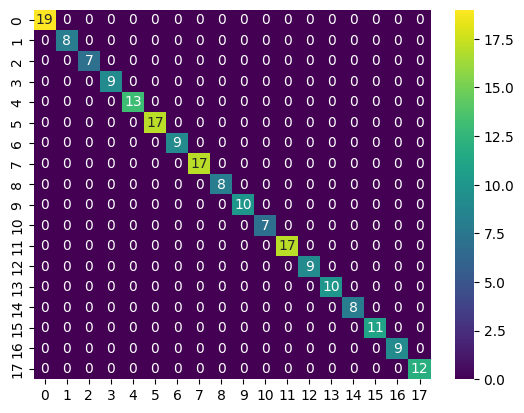

In [ ]:
cf=confusion_matrix(y_test,y_pred)
sns.heatmap(cf,fmt='d',annot=True,cmap='viridis')